# **Análisis *in silico* de variantes termoestables de la proteína Bs-CspB mediante PyRosetta**
### **Autores**: Carlos González Ruiz, Juan Carbonero Mora, Ángela Almendros Marín, María Quero Casado

## **Resumen**
<div align="justify">

La proteína *cold shock* B de *Bacillus subtilis* (Bs‑CspB) es esencial para la adaptación bacteriana a bajas temperaturas. No obstante, su estabilidad térmica es limitada, presentando una temperatura de fusión (Tm) de 53.8ºC. Este rasgo la convierte en un modelo interesante para explorar modificaciones estructurales que puedan alterar la estabilidad global de una proteína. Con esta intención, diseñamos diez variantes de Bs-CspB dirigidas a corregir repulsiones electrostáticas y reforzar el empaquetamiento hidrofóbico. Para ello, seguimos un flujo de trabajo estructurado en tres fases: análisis estructural, diseño racional y guiado por literatura, y evaluación energética mediante PyRosetta. Todas las variantes conservaron el plegamiento nativo, y varias mostraron mejoras energéticas significativas. Entre ellas, los diseños D06 y D01 destacaron por reducir la energía libre de desnaturalización en más de −10 REU y aumentar la temperatura de fusión teórica en más de 70 °C. Estos resultados demuestran que mutaciones estratégicas pueden transformar una proteína marginalmente estable en una variante altamente resistente, consolidando a Bs‑CspB como un modelo predictivo para la ingeniería de proteínas termoestables y abriendo el camino a futuras validaciones experimentales.

</div>

<div align="justify">

**Palabras clave :** *Bacillus subtilis*, Bs-CspB, estabilización térmica, ingeniería de proteínas, diseño computacional,  PyRosetta, `FastRelax`

</div>

## **1. Introducción**



<div align="justify">

La supervivencia bacteriana depende de su capacidad para adaptarse rápidamente a cambios ambientales bruscos, como las fluctuaciones de temperatura. La respuesta al choque térmico, desencadenada por un descenso abrupto en la temperatura, es un mecanismo de conservación que estimula la producción de un grupo específico de proteínas denominadas proteínas *Cold Shock* (CSPs). Estas pequeñas proteínas, presentes en bacterias de todos los rangos térmicos (psicrófilas, mesófilas, termófilas e hipertermófilas), son cruciales para la regulación de la expresión génica bajo condiciones de estrés (Zeeb & Balbach, 2003; Max et al., 2007; Sachs et al., 2012). En *Bacillus subtilis*, una bacteria mesófila modelo, la proteína principal en esta respuesta es CspB. El genoma de *B. subtilis* codifica tres homólogos (CspB, CspC y CspD), cuya síntesis se intensifica notablemente tras un descenso térmico inesperado (Sachs et al., 2012). Su función es actuar como chaperonas de ARN, facilitando la traducción a bajas temperaturas al desestabilizar las estructuras secundarias de los ARNm (Zeeb & Balbach, 2003). De los tres homólogos, CspB es esencial para la viabilidad y el crecimiento celular, convirtiéndose en un sistema modelo ideal para investigar los factores estructurales que determinan la estabilidad proteica (Graumann et al., 1997).

Bs-CspB es una proteína monomérica de 67 residuos con un punto isoeléctrico de 4.3 (Willimsky et al., 1992), cuya estructura tridimensional ha sido resuelta tanto por cristalografía de rayos X como por resonancia magnética nuclear. El plegamiento se compone de un dominio *Cold Shock* (CSD), caracterizado por un barril β antiparalelo de cinco hebras, el cual es distintivo de la superfamilia de plegamientos OB (*oligonucleotide/oligosaccharide-binding fold*) (López et al., 1999). La función biológica de Bs-CspB depende de su capacidad para unirse a ácidos nucleicos de cadena sencilla (ssDNA y ssRNA) a través de una superficie conservada definida por los motivos ribonucleoproteicos RNP I (K13–V20) y RNP II (V26–H29). Estudios estructurales y mutacionales han identificado un conjunto de aproximadamente diecisiete residuos contiguos que constituyen el sitio de unión. Las interacciones se estabilizan mediante el apilamiento de bases y contactos electrostáticos. Aunque la Bs-CspB no muestra una especificidad de secuencia estricta, sí presenta una clara preferencia por oligonucleótidos con alto contenido de timina o uracilo (Zeeb & Balbach, 2003).

A pesar de su estructura compacta y altamente conservada, la Bs-CspB presenta una estabilidad térmica marginal, con una temperatura de fusión (Tm) de solo 53.8 °C y una energía libre de desnaturalización relativamente baja (Max et al., 2007). Esta característica contrasta con la alta termoestabilidad de sus homólogos en organismos termófilos, como Bc-Csp (*Bacillus caldolyticus*) y Tm-Csp (*Thermotoga maritima*), que muestran valores de Tm considerablemente superiores (Wunderlich et al., 2005; Max et al., 2007). Estas diferencias, pese a la alta conservación estructural, convierten a las CSPs en sistemas modelo excepcionales para investigar los principios moleculares de la termoestabilidad proteica. Comparaciones estructurales entre Bs-CspB y Bc-Csp han revelado que la disparidad en la estabilidad se debe principalmente a variaciones en la superficie proteica. De las doce sustituciones de aminoácidos que las diferencian, sólo dos (E3K y E66L) explican un incremento de aproximadamente 15.8 kJ mol⁻¹ en la energía libre de estabilización (Wunderlich et al., 2005). Este hallazgo demuestra que pequeñas modificaciones en la distribución de cargas superficiales pueden tener un impacto significativo sobre la estabilidad global de la proteína al inducir la reorganización de las redes cooperativas de interacciones iónicas y puentes de hidrógeno. Por consiguiente, Bs-CspB se ha consolidado como un modelo experimental fundamental para explorar cómo las interacciones electrostáticas superficiales determinan la energía de plegamiento de proteínas pequeñas.

La ingeniería de proteínas ofrece estrategias complementarias para aumentar la estabilidad térmica: la evolución dirigida *in vitro* y el diseño racional. En Bs-CspB, ambos enfoques han sido aplicados con notable éxito. Mediante del método Proside (*Protein Stability by Directed Evolution*), que vincula la resistencia a proteasas con la estabilidad termodinámica, se han seleccionado variantes con una estabilidad térmica sustancialmente superior a la de la proteína nativa (Wunderlich et al., 2005). Los estudios derivados de esta técnica permitieron identificar un *hotspot* de estabilización localizado en la superficie del barril β, que abarca las hebras β1, β4 y β5, donde se encuentran las mutaciones más eficaces como la triple mutación M1R/E3K/K65I, que destaca por producir un incremento de la Tm desde 53.8 °C hasta 83.7 °C. Este efecto se explica por la combinación de tres mecanismos principales: (1) la optimización electrostática mediante la eliminación de repulsiones desfavorables entre Glu3 y Glu66 y la formación de un nuevo puente salino Arg1–Glu50; (2) el refuerzo hidrofóbico gracias a la sustitución de Lys65 por Ile65, que mejora el empaquetamiento del núcleo proteico; y (3) el establecimiento de puentes de hidrógeno no locales que confieren estabilidad al plegamiento de forma independiente de la fuerza iónica del medio (Max et al., 2007).

La estabilidad de Bs-CspB está intrínsecamente ligada a las interacciones superficiales, demostrando que la modulación de su red electrostática permite un control preciso sobre su energía de plegamiento. No obstante, los mecanismos moleculares que controlan la aditividad y sinergia entre mutaciones estabilizadoras aún no se comprenden completamente. En este contexto, el presente estudio se propone diseñar nuevas variantes de Bs-CspB con mayor estabilidad térmica, basándose en el conocimiento estructural disponible y en la identificación de *hotspots* de inestabilidad. Mediante un enfoque racional orientado a maximizar los efectos cooperativos entre interacciones Van der Waals y contactos hidrofóbicos, se busca profundizar en los principios termodinámicos de la estabilidad proteica y consolidar a Bs-CspB como un modelo predictivo en la ingeniería de proteínas.

</div>

## **2. Métodos**
<div align="justify">

La **Figura 1** muestra como el flujo de trabajo empleado se divide en tres fases principales: (1) el análisis de la estructura *wild type* (WT, 1CSP), (2) el diseño racional de proteínas mutantes mediante el protocolo `FastRelax` y (3) la evaluación cuantitativa de los diseños que han sido generados.

</div>

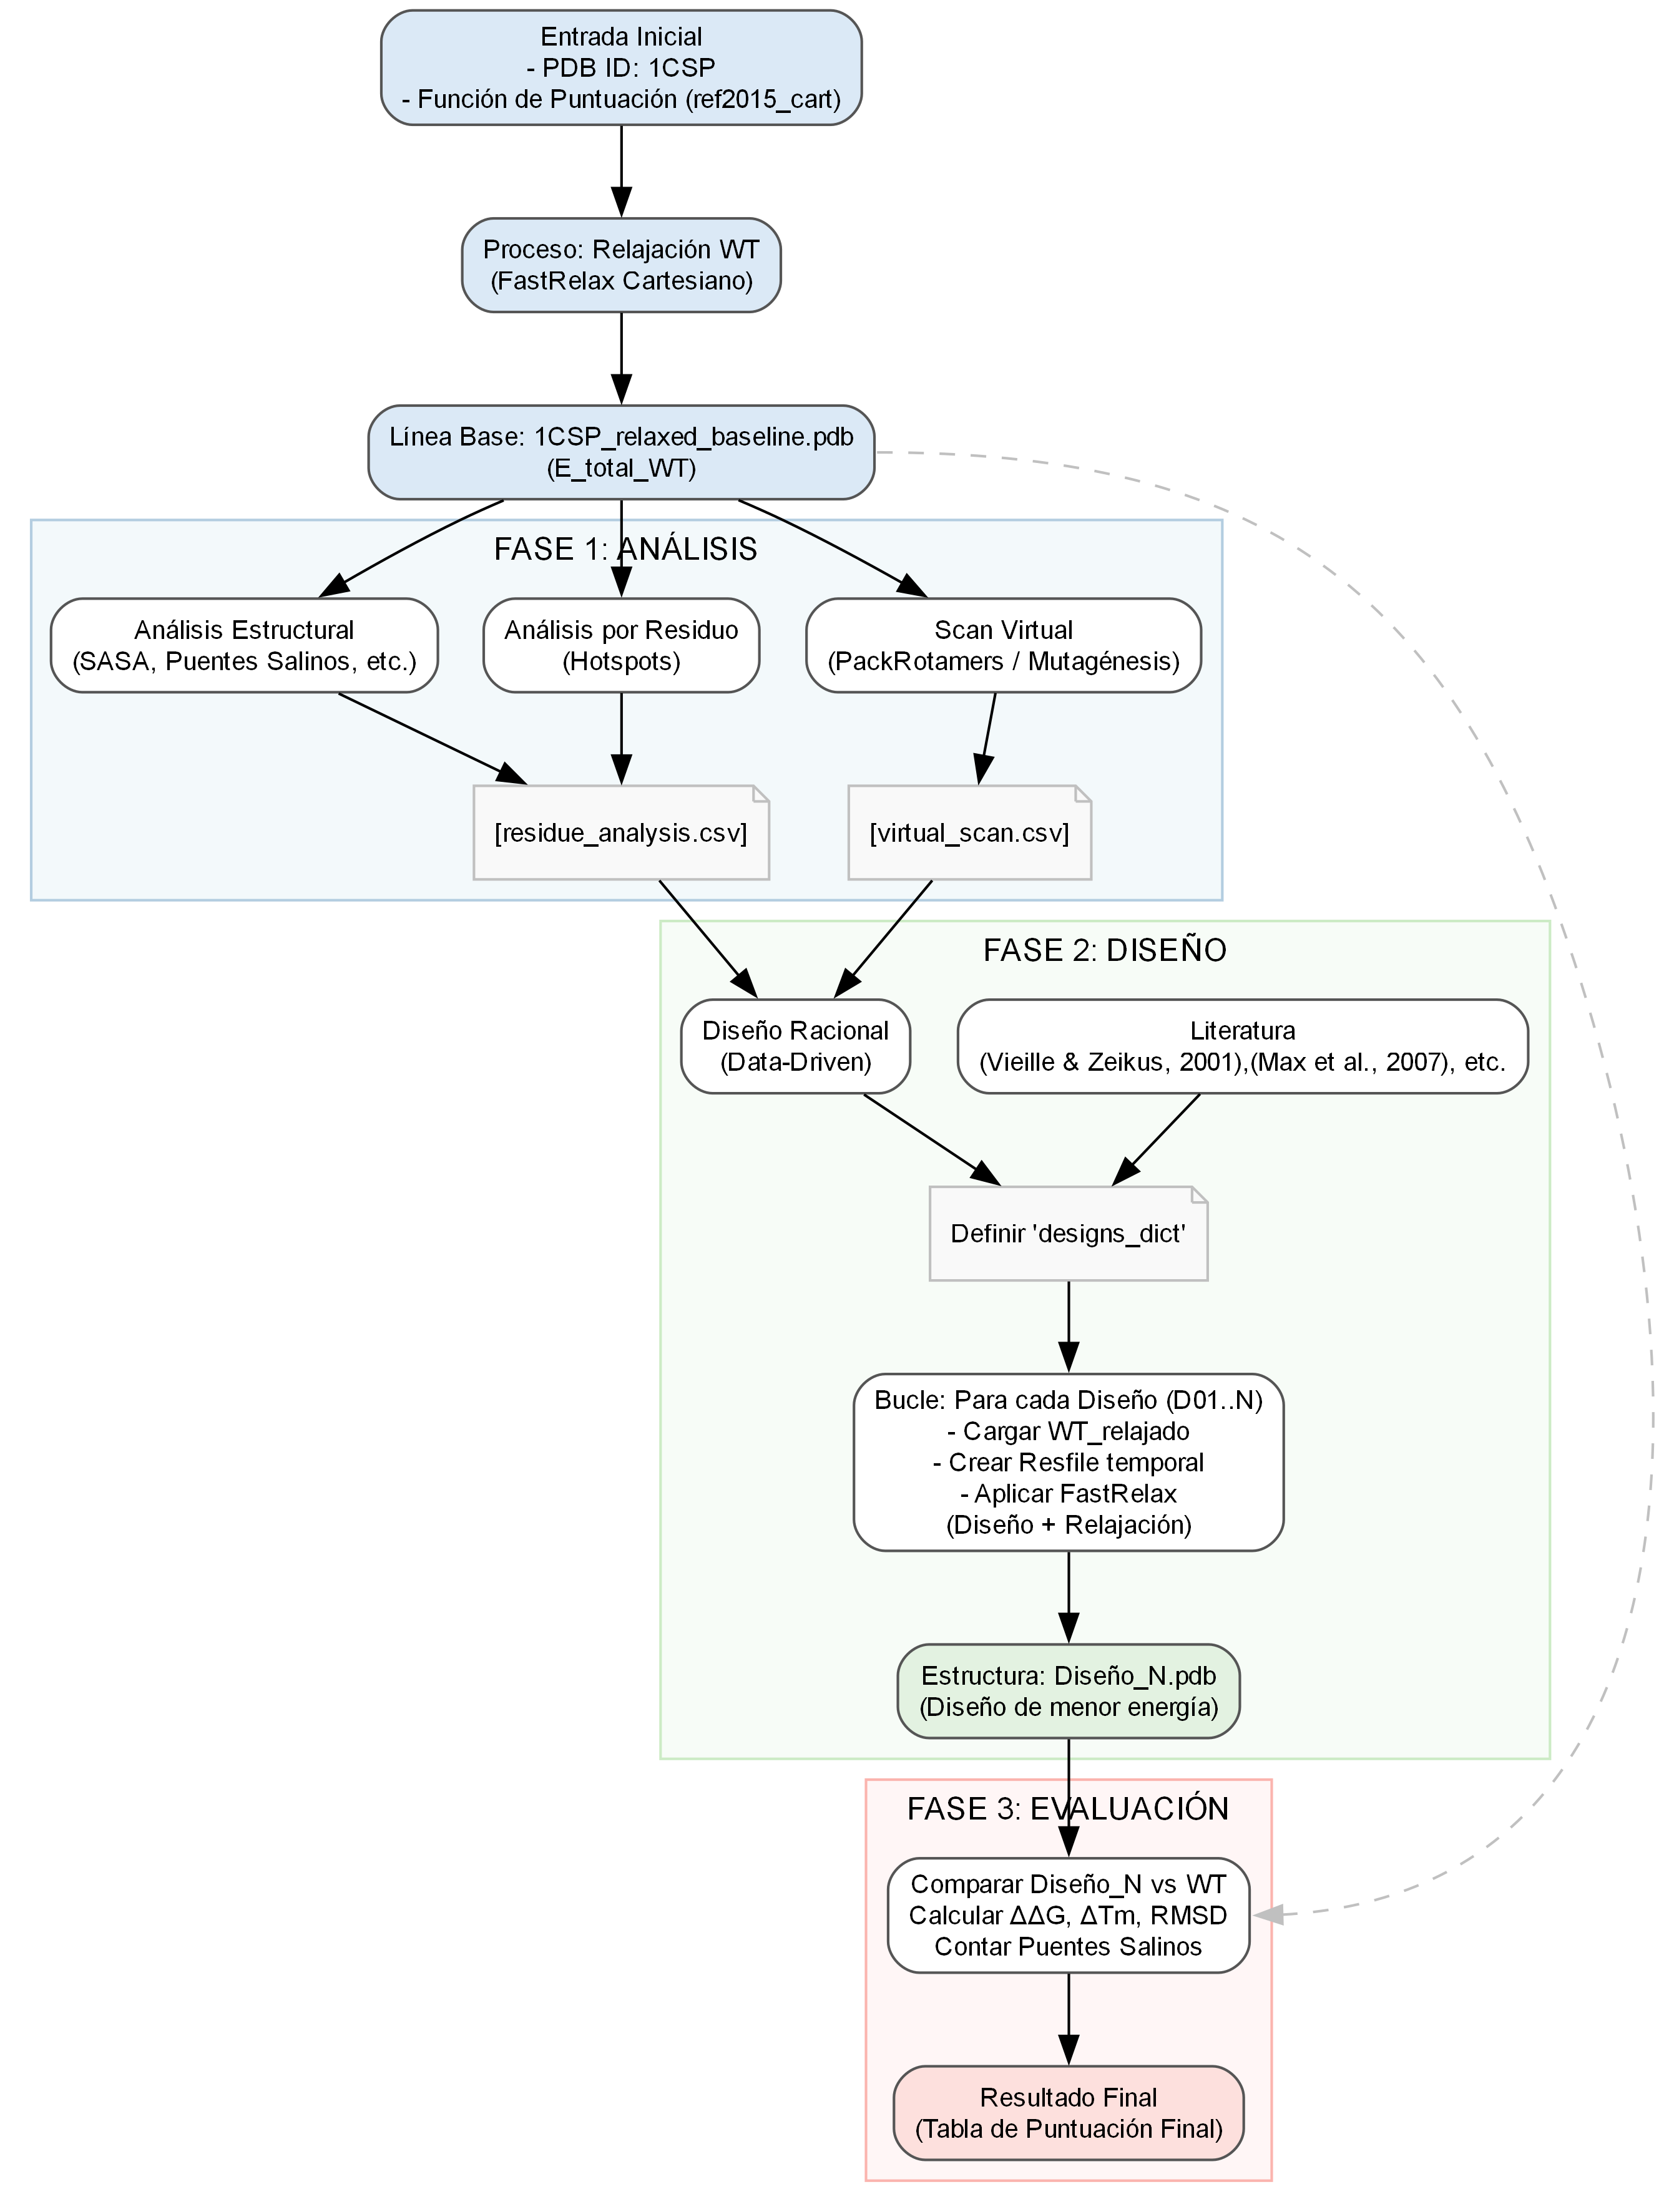
**Figura 1. Esquema del flujo de trabajo computacional para el diseño y la evaluación de los mutantes termoestables de Bs-CspB**

In [1]:
# ==============================================================================
# PROTOCOLO: ANÁLISIS Y DISEÑO DE Bs-CspB (1CSP)
# ==============================================================================

## DESCRIPCIÓN DEL FLUJO DE TRABAJO:
##
## Este script implementa un flujo de trabajo completo para el análisis y el
## rediseño de la proteína Bs-CspB (PDB: 1CSP) usando PyRosetta.
## El protocolo se divide en tres fases principales:
##
## 1. FASE DE ANÁLISIS:
##    - Se carga la estructura silvestre (WT) desde el PDB (1CSP).
##    - Se aplica una "relajación estructural" (FastRelax) para obtener una
##      estructura de referencia (baseline) de baja energía.
##    - Se realiza un análisis estructural detallado (puentes salinos, H-bonds,
##      SASA, SS) sobre la estructura relajada.
##    - Se identifica la contribución energética por residuo ('...residue_analysis.csv')
##      para localizar "puntos críticos" (hotspots) de inestabilidad.
##    - Se ejecuta un escaneo virtual de mutagénesis ('...virtual_scan.csv')
##      para predecir el efecto de mutaciones en cada posición.
##
## 2. FASE DE DISEÑO :
##    - Se define un diccionario de diseños propuestos (basados en el análisis
##      anterior y en la bibliografía).
##    - Cada diseño se aplica a la estructura silvestre relajada mediante un
##      protocolo de "Diseño Relajado" (FastRelax con un resfile).
##
## 3. FASE DE EVALUACIÓN:
##    - Se evalúa cada diseño calculando métricas clave:
##      - Energéticas (Score Total, ΔΔG, ΔTm estimado).
##      - Estructurales (RMSD vs WT, Δfa_rep, Nº Puentes Salinos).
##    - Se generan tablas comparativas y visualizaciones (superposiciones)
##      para seleccionar los diseños más prometedores.
##
## ==============================================================================

# ================================================================
# 1. INSTALACIÓN E INICIALIZACIÓN
# ================================================================
print("[SETUP] Instalando dependencias (PyRosetta, pyDmol, pandas)...")
try:
    import google.colab
    get_ipython().system('pip install pyrosettacolabsetup py3Dmol pandas -q > /dev/null 2>&1')
except (ImportError, NameError):
    print("[WARN] No se detectó un entorno de Colab. Se asume que las librerías ya están instaladas.")

import pyrosettacolabsetup
pyrosettacolabsetup.install_pyrosetta()
print("[INFO] Entorno de librerías listo.")

# ================================================================
# 2. IMPORTS PRINCIPALES
# ================================================================
import os
import tempfile
import pandas as pd
import py3Dmol
from IPython.display import display

# Imports de PyRosetta (Core, Scoring, Relax)
from pyrosetta import *
from pyrosetta.rosetta.core.scoring import (
    CA_rmsd, calpha_superimpose_pose,
    ScoreFunctionFactory, ScoreType, name_from_score_type,
    hbond_sc, hbond_lr_bb, hbond_sr_bb, fa_rep, fa_atr, total_score
)
from pyrosetta.rosetta.protocols.relax import FastRelax
from pyrosetta.rosetta.core.scoring.hbonds import HBondSet
from pyrosetta.toolbox import rcsb

# Imports de PyRosetta (Task, Pack, Minimization)
from pyrosetta.rosetta.core.pack.task import TaskFactory
from pyrosetta.rosetta.core.pack.task.operation import (
    InitializeFromCommandline, IncludeCurrent, ReadResfile,
    OperateOnResidueSubset, PreventRepackingRLT, RestrictToRepackingRLT,
    RestrictAbsentCanonicalAASRLT
)
from pyrosetta.rosetta.core.select.residue_selector import (
    ResidueIndexSelector, NeighborhoodResidueSelector,
    NotResidueSelector, OrResidueSelector
)
from pyrosetta.rosetta.protocols.minimization_packing import PackRotamersMover

# Imports de PyRosetta (Análisis)
from pyrosetta.rosetta.core.scoring.sasa import SasaCalc
from pyrosetta.rosetta.core.scoring.dssp import Dssp

# ================================================================
# 3. FUNCIONES DE PREPARACIÓN Y VISUALIZACIÓN
# ================================================================
def create_and_relax_pose(pdb_id: str, scorefxn) -> Pose:
    """
    Descarga una estructura PDB, la carga y aplica una relajación estructural
    (FastRelax) para generar la estructura de referencia silvestre (WT).
    """
    init("-ex1 -ex2aro -ignore_unrecognized_res -mute all -constant_seed")
    print(f"[PROCESS] Descargando y cargando PDB ID: {pdb_id}...")
    pose_initial = rcsb.pose_from_rcsb(pdb_id, ATOM=True, CRYS=False)

    pose_relaxed = Pose()
    pose_relaxed.assign(pose_initial)

    E_before = scorefxn(pose_initial)
    print("[PROCESS] Iniciando relajación Cartesiana (1 ciclo)...")

    relax = FastRelax(scorefxn_in=scorefxn, standard_repeats=1)
    relax.cartesian(True)
    relax.apply(pose_relaxed)

    E_after = pose_relaxed.energies().total_energy()
    print(f"[INFO] Energía antes de relax: {E_before:.3f} REU | Después de relax: {E_after:.3f} REU")
    return pose_relaxed

def display_pose(pose: Pose, title: str) -> py3Dmol.view:
    """
    Muestra una pose en 3D usando py3Dmol.
    """
    with tempfile.NamedTemporaryFile(suffix=".pdb") as tmp:
        pose.dump_pdb(tmp.name)
        pdb_str = open(tmp.name).read()

    viewer = py3Dmol.view(width=700, height=450)
    viewer.addModel(pdb_str, "pdb")
    viewer.setStyle({"cartoon": {"color": "spectrum"}})
    viewer.zoomTo()
    print(f"\n[OUTPUT] Visualización 3D: {title}")
    return viewer.show()

def display_superposition(pose_ref: Pose, pose_mobile: Pose, title_ref: str, title_mobile: str) -> py3Dmol.view:
    """
    Superpone dos poses (móvil en rojo, referencia en azul) tras alinearlas.
    """
    mobile_aligned = Pose()
    mobile_aligned.assign(pose_mobile)
    calpha_superimpose_pose(mobile_aligned, pose_ref)

    with tempfile.NamedTemporaryFile(suffix=".pdb") as tmp_ref, tempfile.NamedTemporaryFile(suffix=".pdb") as tmp_mobile:
        pose_ref.dump_pdb(tmp_ref.name)
        pdb_str_ref = open(tmp_ref.name).read()
        mobile_aligned.dump_pdb(tmp_mobile.name)
        pdb_str_mobile = open(tmp_mobile.name).read()

    viewer = py3Dmol.view(width=800, height=500)
    viewer.addModel(pdb_str_ref, "pdb")
    viewer.setStyle({'model': 0}, {"cartoon": {"color": "blue", "opacity": 0.8}})
    viewer.addModel(pdb_str_mobile, "pdb")
    viewer.setStyle({'model': 1}, {"cartoon": {"color": "red"}})
    viewer.zoomTo()
    print(f"\n[OUTPUT] Superposición: {title_ref} (Azul) vs. {title_mobile} (Rojo)")
    return viewer.show()

# ================================================================
# 4. FUNCIONES DEL FLUJO DE TRABAJO DE ANÁLISIS
# ================================================================
def analyze_structural_features(pose: Pose, salt_bridge_cutoff: float, verbose=True) -> dict:
    """
    Calcula el número de puentes de hidrógeno (totales, BB, SC) y
    puentes salinos en una pose. Devuelve un diccionario con los resultados.
    """
    if verbose:
        print("\n--- 1. Análisis de H-Bonds y Puentes Salinos ---")

    # 1. Cálculo de Puentes de Hidrógeno
    hbond_set = HBondSet()
    hbond_set.setup_for_residue_pair_energies(pose, False, False)

    total_hbonds = hbond_set.nhbonds()
    bb_hbonds = sum(1 for h in hbond_set.hbonds() if h.don_hatm_is_backbone() and h.acc_atm_is_backbone())
    sc_hbonds = total_hbonds - bb_hbonds

    if verbose:
        print(f"  [INFO] Puentes de Hidrógeno (Total): {total_hbonds}")
        print(f"         - Backbone-Backbone (BB): {bb_hbonds}")
        print(f"         - Sidechain/Otros (SC):   {sc_hbonds}")

    # 2. Cálculo de Puentes Salinos
    salt_bridges_list = []
    pos_charged_set = {'LYS', 'ARG'}
    atom_map = {'LYS': 'NZ', 'ARG': 'CZ', 'ASP': 'CG', 'GLU': 'CD'}
    charged_res_indices = [i for i in range(1, pose.total_residue() + 1) if pose.residue(i).name3() in atom_map]

    for i in range(len(charged_res_indices)):
        for j in range(i + 1, len(charged_res_indices)):
            res_idx1, res_idx2 = charged_res_indices[i], charged_res_indices[j]
            res1, res2 = pose.residue(res_idx1), pose.residue(res_idx2)
            name1 = res1.name3()
            name2 = res2.name3()
            is_pos1 = name1 in pos_charged_set
            is_pos2 = name2 in pos_charged_set

            # Comprobar que son cargas opuestas
            if is_pos1 != is_pos2:
                atom1 = res1.atom(atom_map[name1])
                atom2 = res2.atom(atom_map[name2])
                dist = atom1.xyz().distance(atom2.xyz())
                if dist < salt_bridge_cutoff:
                    salt_bridges_list.append(f"{res_idx1:3d} {name1:3s} <-> {res_idx2:3d} {name2:3s}  ({dist:.2f} Å)")

    if verbose:
        print(f"  [INFO] Puentes Salinos (Cutoff < {salt_bridge_cutoff} Å): {len(salt_bridges_list)}")
        for sb in salt_bridges_list:
            print(f"    - {sb}")

    return {"Salt Bridges List": salt_bridges_list, "Nº Puentes Salinos": len(salt_bridges_list),
            "Nº H-Bonds (BB)": bb_hbonds, "Nº H-Bonds (SC)": sc_hbonds, "Nº H-Bonds (Total)": total_hbonds}

def analyze_secondary_structure_dssp(pose: Pose):
    """
    Analiza y reporta la composición de estructura secundaria
    (Hélice, Hoja, Lazo) usando DSSP.
    """
    print("\n--- 2. Análisis de Estructura Secundaria (Dssp) ---")
    dssp = Dssp(pose)
    ss_seq = dssp.get_dssp_secstruct()

    print(f"  [SECUENCIA SS] {ss_seq}")
    print(f"  [SECUENCIA AA] {pose.sequence()}")

    n_sheet = ss_seq.count('E')
    n_helix = ss_seq.count('H')
    n_loop = ss_seq.count('L')
    total = len(ss_seq)

    print("  [RESUMEN]")
    print(f"     - Hojas-Beta (E): {n_sheet:3d} res ({n_sheet/total*100:5.1f}%)")
    print(f"     - Hélices-Alfa (H): {n_helix:3d} res ({n_helix/total*100:5.1f}%)")
    print(f"     - Loops/Coils  (L): {n_loop:3d} res ({n_loop/total*100:5.1f}%)")

def analyze_sasa(pose: Pose):
    """
    Calcula y reporta el Área Accesible al Solvente (SASA) total,
    hidrofóbica y polar de la pose.
    """
    print("\n--- 3. Análisis de Área Accesible al Solvente (SASA) ---")
    sasa_calc = SasaCalc()
    sasa_calc.calculate(pose)

    total_sasa = sasa_calc.get_total_sasa()
    hp_sasa = 0.0
    pol_sasa = 0.0

    residue_sasas = sasa_calc.get_residue_sasa()

    for i in range(1, pose.total_residue() + 1):
        res = pose.residue(i)
        if not res.is_protein(): continue
        res_sasa = residue_sasas[i]
        if res.is_polar():
            pol_sasa += res_sasa
        else:
            hp_sasa += res_sasa

    print("  [RESUMEN SASA (Å²)]")
    print(f"     - SASA Total:        {total_sasa:8.2f} Å²")
    if total_sasa > 0:
        print(f"     - SASA Hidrofóbica:   {hp_sasa:8.2f} Å²  ({hp_sasa/total_sasa*100:5.1f}%)")
        print(f"     - SASA Polar:         {pol_sasa:8.2f} Å²  ({pol_sasa/total_sasa*100:5.1f}%)")
    else:
        print(f"     - SASA Hidrofóbica:   {hp_sasa:8.2f} Å²")
        print(f"     - SASA Polar:         {pol_sasa:8.2f} Å²")

def analyze_per_residue_properties(pose: Pose, scorefxn, output_filename: str):
    """
    Genera un análisis detallado por residuo (Energía, SASA, SS) y lo guarda
    en un CSV. Identifica y reporta posibles defectos estructurales (BUNS, clashes, huecos).
    """
    print("\n--- 4. Análisis Detallado por Residuo (Energía, SASA, SS) ---")
    sasa_calc = SasaCalc()
    sasa_calc.calculate(pose)
    dssp = Dssp(pose)

    ss_seq = dssp.get_dssp_secstruct()
    residue_sasas = sasa_calc.get_residue_sasa()

    pol_res_types = ["SER", "THR", "ASN", "GLN", "ASP", "GLU", "LYS", "ARG", "HIS", "TYR"]

    residue_data = []

    for i in range(1, pose.total_residue() + 1):
        res = pose.residue(i)
        if not res.is_protein(): continue

        res_name = res.name3()
        energies = pose.energies().residue_total_energies(i)

        total_e = energies[total_score]
        fa_rep_e = energies[fa_rep]
        fa_atr_e = energies[fa_atr]
        hbond_e = energies[hbond_sc] + energies[hbond_lr_bb] + energies[hbond_sr_bb]

        res_sasa = residue_sasas[i]
        res_ss = ss_seq[i-1]

        residue_data.append({
            "Res": f"{res_name}{i}",
            "SS": res_ss,
            "SASA": res_sasa,
            "Total E": total_e,
            "fa_rep": fa_rep_e,
            "fa_atr": fa_atr_e,
            "H-Bond E": hbond_e,
            "Polar": res_name in pol_res_types
        })

    df = pd.DataFrame(residue_data)

    try:
        df.to_csv(output_filename, index=False, float_format="%.3f")
        print(f"\n  [INFO] Tabla de análisis por residuo guardada en: {output_filename}")
    except Exception as e:
        print(f"\n  [ERROR] No se pudo guardar el archivo CSV: {e}")

    print("\n  [TABLA DE DATOS POR RESIDUO (Primeros 15)]")
    with pd.option_context('display.max_rows', 15, 'display.max_columns', None, 'display.width', 1000):
        display(df.head(15))

    print("\n  [DIAGNÓSTICO: Posibles Polares Enterrados No Satisfechos (BUNS)]")
    print("  (Polares con baja SASA y mala energía total, indicando que no forman H-bonds)")
    buns = df[(df['Polar'] == True) & (df['SASA'] < 25) & (df['Total E'] > 1.0)]
    if buns.empty:
        print("  > No se detectaron BUNS obvios.")
    else:
        display(buns)
        print("  > ESTRATEGIA: Mutar estos residuos a hidrofóbicos (ej. S_a_A, T_a_V).")

    print("\n  [DIAGNÓSTICO: Posibles Clashes de Empaquetamiento]")
    print("  (Residuos con alta energía repulsiva 'fa_rep')")
    clashes = df[df['fa_rep'] > 5.0]
    if clashes.empty:
        print("  > No se detectaron clashes de empaquetamiento severos.")
    else:
        display(clashes)
        print("  > ESTRATEGIA: Mutar estos residuos a unos más pequeños (ej. F_a_L, L_a_V).")

    print("\n  [DIAGNÓSTICO: Posibles 'Huecos' de Empaquetamiento]")
    print("  (Residuos enterrados que NO tienen energía atractiva 'fa_atr')")
    holes = df[(df['Polar'] == False) & (df['SASA'] < 25) & (df['fa_atr'] > -1.0)]
    if holes.empty:
        print("  > No se detectaron 'huecos' obvios.")
    else:
        display(holes)
        print("  > ESTRATEGIA: Mutar estos residuos a unos más grandes (ej. A_a_L, V_a_F).")

def analyze_virtual_mutagenesis_scan(pose: Pose, scorefxn, output_filename: str):
    """
    Realiza un escaneo de mutagénesis virtual ("in silico saturation mutagenesis")
    para cada residuo, probando 19 mutaciones (excluyendo Cys) y reportando
    la mejor mutación y su ΔE.
    """
    print("\n--- 5. Análisis de Escaneo de Mutagénesis Virtual ---")
    print("  [INFO] Este análisis probará 19 mutaciones en las 67 posiciones.")
    print("  [INFO] ... esto puede tardar unos minutos (aprox. 1-3 min) ...")

    E_before = pose.energies().total_energy()
    wt_seq = pose.sequence()
    scan_data = []

    packer = PackRotamersMover(scorefxn)
    design_op = RestrictAbsentCanonicalAASRLT()
    design_op.aas_to_keep("ADEFGHIKLMNPQRSTVWY") # Excluye Cys

    for i in range(1, pose.total_residue() + 1):
        scan_pose = Pose()
        scan_pose.assign(pose)

        # 1. Definir selectores
        target_res = ResidueIndexSelector(i)
        neighbors_only = NeighborhoodResidueSelector(target_res, 6.0, False)
        mobile_region = OrResidueSelector(target_res, neighbors_only)
        everyone_else = NotResidueSelector(mobile_region)

        # 2. Crear TaskFactory
        tf = TaskFactory()
        tf.push_back(InitializeFromCommandline())
        tf.push_back(IncludeCurrent())
        tf.push_back(OperateOnResidueSubset(PreventRepackingRLT(), everyone_else))      # No mover el resto
        tf.push_back(OperateOnResidueSubset(RestrictToRepackingRLT(), neighbors_only)) # Repaquetar vecinos
        tf.push_back(OperateOnResidueSubset(design_op, target_res))                     # Mutar el objetivo

        # 3. Aplicar
        task = tf.create_task_and_apply_taskoperations(scan_pose)
        packer.task(task)
        packer.apply(scan_pose)

        # 4. Registrar resultados
        E_after = scan_pose.energies().total_energy()
        delta_E = E_after - E_before
        wt_aa = wt_seq[i-1]
        mut_aa = scan_pose.residue(i).name1()

        scan_data.append({
            "ResNum": i,
            "WT_AA": wt_aa,
            "Best_Mut": mut_aa,
            "Delta_E": delta_E,
            "SS": pose.secstruct(i)
        })

        if i % 10 == 0:
            print(f"  ... escaneando residuo {i}/{pose.total_residue()} ...")

    df_scan = pd.DataFrame(scan_data)
    df_scan = df_scan.sort_values(by="Delta_E").reset_index(drop=True)

    try:
        df_scan.to_csv(output_filename, index=False, float_format="%.3f")
        print(f"\n  [INFO] Tabla del escaneo virtual guardada en: {output_filename}")
    except Exception as e:
        print(f"\n  [ERROR] No se pudo guardar el archivo CSV del escaneo: {e}")

    print("\n  [DIAGNÓSTICO: Mejores Candidatos para Mutación (Top 15)]")
    print("  (Residuos donde Rosetta encontró una mutación favorable)")
    with pd.option_context('display.max_rows', 15, 'display.max_columns', None, 'display.width', 1000):
        display(df_scan.head(15))

# ================================================================
# 5. FUNCIONES DEL FLUJO DE TRABAJO DE DISEÑO
# ================================================================
def apply_single_design(base_pose: Pose, resfile_content: str, scorefxn) -> Pose:
    """
    Aplica un diseño a una pose base usando un 'resfile' y el
    protocolo FastRelax. Esta función ejecuta el "Diseño Relajado".
    """
    init("-ex1 -ex2aro -ignore_unrecognized_res -mute all -constant_seed")

    # Escribir el contenido del resfile en un archivo temporal
    with tempfile.NamedTemporaryFile(mode="w", suffix=".resfile", delete=False) as tmp:
        tmp.write(resfile_content)
        resfile_path = tmp.name

    pose_design = Pose()
    pose_design.assign(base_pose)

    # Configurar el TaskFactory para leer el resfile
    task_factory = TaskFactory()
    task_factory.push_back(InitializeFromCommandline())
    task_factory.push_back(IncludeCurrent())
    task_factory.push_back(ReadResfile(resfile_path))

    print("  [Design Relax] Iniciando protocolo de Diseño Relajado (1 ciclo)...")
    relax_design = FastRelax(scorefxn_in=scorefxn, standard_repeats=1)
    relax_design.cartesian(True)
    relax_design.set_task_factory(task_factory) # Aplicar el resfile durante la relajación

    # Ejecutar el protocolo
    relax_design.apply(pose_design)

    os.remove(resfile_path) # Limpiar el archivo temporal
    return pose_design

def generate_alignment_and_mutations(wt_pose: Pose, design_pose: Pose) -> tuple:
    """
    Compara las secuencias de dos poses (referencia y diseño) para generar
    un alineamiento de texto y una lista de las mutaciones introducidas.
    """
    wt_seq = wt_pose.sequence()
    design_seq = design_pose.sequence()

    match_chars = []
    mutations_found = []

    for i in range(len(wt_seq)):
        wt_aa = wt_seq[i]
        design_aa = design_seq[i]
        res_num = i + 1

        if wt_aa == design_aa:
            match_chars.append("|")
        else:
            match_chars.append(" ")
            mutations_found.append(f"{wt_aa}{res_num}{design_aa}")

    match_line = "".join(match_chars)
    chunk_size = 60
    output_lines = []

    for i in range(0, len(wt_seq), chunk_size):
        start = i
        end = i + chunk_size
        output_lines.append(f"  WT:     {start+1:<4} {wt_seq[start:end]}")
        output_lines.append(f"          {'':<4} {match_line[start:end]}")
        output_lines.append(f"  Design: {start+1:<4} {design_seq[start:end]}\n")

    mutation_str = f"  Mutaciones Confirmadas: {', '.join(mutations_found) or 'Ninguna'}"
    output_lines.append(mutation_str)

    return "\n".join(output_lines), mutations_found

def run_design_and_evaluation(base_pose: Pose, designs_dict: dict, scorefxn, criteria: dict, config: dict) -> tuple:
    """
    Bucle principal de diseño. Itera sobre un diccionario de diseños, ejecuta
    'apply_single_design' para cada uno, y evalúa los resultados (ΔΔG, RMSD, etc.),
    generando al final las tablas resumen.
    """
    print("\n" + "="*60 + "\n INICIANDO PROCESO DE DISEÑO Y EVALUACIÓN\n" + "="*60)

    output_dir = "design_results"
    os.makedirs(output_dir, exist_ok=True)
    print(f"[INFO] Las poses de los diseños se guardarán en la carpeta: '{output_dir}'")

    summary_results, energy_breakdowns = [], {}
    E_wt_relaxed = base_pose.energies().total_energy()

    # Analiza la estructura silvestre (WT) para obtener el número base de puentes salinos
    wt_structural_features = analyze_structural_features(base_pose, config["SALT_BRIDGE_DISTANCE_CUTOFF"], verbose=False)
    num_salt_bridges_wt = wt_structural_features['Nº Puentes Salinos']

    tm_wt = config.get("TM_SILVESTRE_C", 49.0)
    print(f"[INFO] Tm de referencia (Silvestre): {tm_wt:.1f} °C")

    for name, resfile_content in designs_dict.items():
        print(f"\n--- Analizando: {name} ---")

        # 1. Aplicar el diseño
        pose_design = apply_single_design(base_pose, resfile_content, scorefxn)
        output_pdb_path = os.path.join(output_dir, f"{name}.pdb")
        pose_design.dump_pdb(output_pdb_path)

        # 2. Analizar secuencia y mutaciones
        alignment_output, mutation_list = generate_alignment_and_mutations(base_pose, pose_design)
        print(alignment_output)
        num_muts = len(mutation_list)

        # 3. Analizar conservación estructural
        rmsd_value = CA_rmsd(base_pose, pose_design)
        print(f"  Conservación Estructural (RMSD vs WT): {rmsd_value:.3f} Å")

        # 4. Analizar características (Puentes Salinos, H-bonds)
        structural_features = analyze_structural_features(pose_design, config["SALT_BRIDGE_DISTANCE_CUTOFF"], verbose=False)
        print(f"  Puentes Salinos: {structural_features['Nº Puentes Salinos']}")
        for sb in structural_features['Salt Bridges List']: print(f"    - {sb}")
        print(f"  Puentes de Hidrógeno (Total): {structural_features['Nº H-Bonds (Total)']}")
        print(f"    - Backbone: {structural_features['Nº H-Bonds (BB)']}")
        print(f"    - Sidechain: {structural_features['Nº H-Bonds (SC)']}")

        # 5. Calcular métricas de energía y estabilidad
        E_design = pose_design.energies().total_energy()
        ddG = E_design - E_wt_relaxed
        delta_fa_rep = pose_design.energies().total_energies()[ScoreType.fa_rep] - \
                       base_pose.energies().total_energies()[ScoreType.fa_rep]

        meets_criteria = (ddG < criteria["ddG_threshold"] and
                          delta_fa_rep < criteria["fa_rep_increase_limit"] and
                          rmsd_value < criteria["rmsd_threshold"])

        # 6. Calcular Score de Estabilidad ponderado
        efficiency_factor = 1.0 if num_muts <= 3 else 0.9 if num_muts <= 6 else 0.8
        stability_score = ddG * efficiency_factor

        bonus_applied = "✗ No"
        if structural_features['Nº Puentes Salinos'] > num_salt_bridges_wt:
            stability_score *= 1.05 # Bonificación por nuevos puentes salinos
            bonus_applied = "✓ Sí"

        # 7. Estimar Tm
        delta_tm_estimado = -7.1 * ddG # Aproximación lineal
        tm_design = tm_wt + delta_tm_estimado

        # 8. Guardar resultados
        summary_entry = {
            "Diseño": name, "Nº Mutaciones": num_muts, "RMSD (Å)": rmsd_value,
            "Energía Total (REU)": E_design, "ΔΔG (REU)": ddG, "Δfa_rep (REU)": delta_fa_rep,
            "Exitoso": "✓ Sí" if meets_criteria else "✗ No",
            "Bonus SB": bonus_applied,
            "Score Estabilidad": stability_score,
            "ΔTm Estimado (°C)": delta_tm_estimado,
            "Tm Diseño (°C)": tm_design,
        }
        summary_entry.update(structural_features)
        summary_results.append(summary_entry)

        # 9. Guardar desglose energético
        emap = pose_design.energies().total_energies()
        energy_breakdowns[name] = {name_from_score_type(stype): emap[stype] for stype in scorefxn.get_nonzero_weighted_scoretypes()}

        # 10. Visualizar diseños exitosos
        if meets_criteria:
            display_superposition(base_pose, pose_design, "Silvestre Relajada", f"Diseño Exitoso: {name}")

    # --- Generar Reportes de Diseño ---
    print("\n" + "="*60 + "\n DESGLOSE ENERGÉTICO COMPARATIVO (REU)\n" + "="*60)

    wt_emap = base_pose.energies().total_energies()
    energy_breakdowns["Silvestre (WT)"] = {
        name_from_score_type(stype): wt_emap[stype] for stype in scorefxn.get_nonzero_weighted_scoretypes()}

    design_keys = [name for name in designs_dict.keys() if name in energy_breakdowns]
    df_energies = pd.DataFrame(energy_breakdowns)[["Silvestre (WT)"] + design_keys]
    display(df_energies.style.format("{:.3f}"))

    print("\n" + "="*60 + "\n RESULTADOS FINALES DE LOS DISEÑOS\n" + "="*60)

    df_summary = pd.DataFrame(summary_results).sort_values("Score Estabilidad").reset_index(drop=True)

    pre_cols = ["Diseño", "Energía Total (REU)", "ΔΔG (REU)", "Score Estabilidad", "ΔTm Estimado (°C)", "Tm Diseño (°C)"]
    post_cols = ["Nº Mutaciones", "Nº Puentes Salinos", "Bonus SB", "Δfa_rep (REU)", "RMSD (Å)", "Exitoso"]
    all_cols = pre_cols + post_cols

    display(df_summary[[col for col in all_cols if col in df_summary.columns]])

    return df_summary, energy_breakdowns

# ================================================================
# 6. EJECUCIÓN DEL FLUJO DE TRABAJO
# ================================================================
def main():
    """
    Función principal que orquesta todo el flujo de trabajo:
    Configuración, Inicialización, Relajación, Análisis y Diseño.
    """
    # --- Configuración Global ---
    CONFIG = {
        "PDB_ID": "1CSP",
        "TM_SILVESTRE_C": 49.0, # Tm de la proteína silvestre
        "SALT_BRIDGE_DISTANCE_CUTOFF": 4.0,

        # Criterios de aceptación para un diseño exitoso
        "DESIGN_CRITERIA": {
            "ddG_threshold": -2.0,           # Debe ser energéticamente favorable
            "fa_rep_increase_limit": 20.0,   # No debe introducir clashes severos
            "rmsd_threshold": 2.0            # Debe mantener el plegamiento
        },

        # Nombres de archivos de salida
        "RESIDUE_ANALYSIS_FILENAME": "1CSP_residue_analysis.csv",
        "VIRTUAL_SCAN_FILENAME": "1CSP_virtual_scan.csv"
    }

    # --- 1. Inicialización de PyRosetta ---
    print("="*60)
    print("INICIANDO SCRIPT: ANÁLISIS Y DISEÑO DE 1CSP (WT)")
    print("="*60)
    init("-ex1 -ex2aro -ignore_unrecognized_res -mute all -constant_seed")
    print("[SETUP] PyRosetta inicializado en modo determinista (semilla fija: 1111111).")
    scorefxn = create_score_function("ref2015_cart.wts")
    print("[INFO] Usando la función de puntuación 'ref2015_cart.wts'.")

    # --- 2. Carga y Relajación (Se hace UNA SOLA VEZ) ---
    pose_relaxed_wt = create_and_relax_pose(CONFIG["PDB_ID"], scorefxn)

    relaxed_pdb_filename = f"{CONFIG['PDB_ID']}_silvestre_relajada.pdb"
    pose_relaxed_wt.dump_pdb(relaxed_pdb_filename)
    print(f"[INFO] La estructura silvestre relajada (referencia) se ha guardado como '{relaxed_pdb_filename}'")

    display_pose(pose_relaxed_wt, title=f"Estructura Silvestre Relajada ({CONFIG['PDB_ID']})")


    # ================================================================
    # --- 3. FASE DE ANÁLISIS ESTRUCTURAL ---
    # ================================================================
    print("\n" + "="*66)
    print(f" INICIANDO ANÁLISIS ESTRUCTURAL DE {CONFIG['PDB_ID']} (RELAJADO) ")
    print("="*66)

    # Ejecutar Módulos de Análisis (1-4)
    analyze_structural_features(pose_relaxed_wt, CONFIG["SALT_BRIDGE_DISTANCE_CUTOFF"], verbose=True)
    analyze_secondary_structure_dssp(pose_relaxed_wt)
    analyze_sasa(pose_relaxed_wt)
    analyze_per_residue_properties(
        pose_relaxed_wt,
        scorefxn,
        CONFIG["RESIDUE_ANALYSIS_FILENAME"]
    )

    # Ejecutar Módulo de Análisis (5)
    analyze_virtual_mutagenesis_scan(
        pose_relaxed_wt,
        scorefxn,
        CONFIG["VIRTUAL_SCAN_FILENAME"]
    )
    print("\n" + "="*60 + "\nANÁLISIS ESTRUCTURAL COMPLETADO\n" + "="*60)

    # ================================================================
    # --- 4. FASE DE DISEÑO RACIONAL ---
    # ================================================================

    # Diccionario de diseños (formato Resfile)
    # Los diseños están justificados por el análisis anterior (archivos CSV) y bibliografía.
    designs = {
        "D01": """
NATRO
START
8 A PIKAA K
11 A PIKAA P
46 A PIKAA K
48 A PIKAA R
""",

        "D02": """
NATRO
START
13 A PIKAA L
30 A PIKAA A
64 A PIKAA V
""",

        "D03": """
NATRO
START
10 A PIKAA D
34 A PIKAA L
67 A PIKAA S
""",

        "D04": """
NATRO
START
1 A PIKAA R
3 A PIKAA K
66 A PIKAA K
""",

        "D05": """
NATRO
START
12 A PIKAA Y
46 A PIKAA K
48 A PIKAA R
""",

        "D06": """
NATRO
START
3 A PIKAA R
66 A PIKAA L
46 A PIKAA K
48 A PIKAA R
""",

        "D07": """
NATRO
START
3 A PIKAA R
1 A PIKAA I
46 A PIKAA K
48 A PIKAA R
""",

        "D08": """
NATRO
START
54 A PIKAA R
62 A PIKAA D
64 A PIKAA K
""",

        "D09": """
NATRO
START
46 A PIKAA L
66 A PIKAA V
""",

        "D10": """
NATRO
START
3 A PIKAA V
46 A PIKAA L
64 A PIKAA R
66 A PIKAA V
"""
    }

    # Ejecutar el bucle principal de diseño y evaluación
    run_design_and_evaluation(
        base_pose=pose_relaxed_wt,
        designs_dict=designs,
        scorefxn=scorefxn,
        criteria=CONFIG["DESIGN_CRITERIA"],
        config=CONFIG
    )

if __name__ == "__main__":
    main()

[SETUP] Instalando dependencias (PyRosetta, pyDmol, pandas)...
Mounted at /content/google_drive

Note that USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE.
See https://github.com/RosettaCommons/rosetta/blob/main/LICENSE.md or email license@uw.edu for details.

Looking for compatible PyRosetta wheel file at google-drive/PyRosetta/colab.bin//wheels...
Found compatible wheel: /content/google_drive/MyDrive/PyRosetta/colab.bin/wheels//content/google_drive/MyDrive/PyRosetta/colab.bin/wheels/pyrosetta-2025.45+release.d79cb06334-cp312-cp312-linux_x86_64.whl


[INFO] Entorno de librerías listo.
INICIANDO SCRIPT: ANÁLISIS Y DISEÑO DE 1CSP (WT)
┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│      

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


 INICIANDO ANÁLISIS ESTRUCTURAL DE 1CSP (RELAJADO) 

--- 1. Análisis de H-Bonds y Puentes Salinos ---
  [INFO] Puentes de Hidrógeno (Total): 48
         - Backbone-Backbone (BB): 39
         - Sidechain/Otros (SC):   9
  [INFO] Puentes Salinos (Cutoff < 4.0 Å): 2
    -   5 LYS <->  19 GLU  (3.85 Å)
    -   7 LYS <->  25 ASP  (3.32 Å)

--- 2. Análisis de Estructura Secundaria (Dssp) ---
  [SECUENCIA SS] LEEEEEEEEELLLLEEEEEELLEEEEEEEHHHELLLLLLLLLLLLEEEEEEEEELLEEEEEEEEEEL
  [SECUENCIA AA] MLEGKVKWFNSEKGFGFIEVEGQDDVFVHFSAIQGEGFKTLEEGQAVSFEIVEGNRGPQAANVTKEA
  [RESUMEN]
     - Hojas-Beta (E):  42 res ( 62.7%)
     - Hélices-Alfa (H):   3 res (  4.5%)
     - Loops/Coils  (L):  22 res ( 32.8%)

--- 3. Análisis de Área Accesible al Solvente (SASA) ---
  [RESUMEN SASA (Å²)]
     - SASA Total:         4418.25 Å²
     - SASA Hidrofóbica:    1454.91 Å²  ( 32.9%)
     - SASA Polar:          2963.34 Å²  ( 67.1%)

--- 4. Análisis Detallado por Residuo (Energía, SASA, SS) ---

  [INFO] Tabla de anális

,Res,SS,SASA,Total E,fa_rep,fa_atr,H-Bond E,Polar
0,MET1,L,114.415672,-2.878136,1.018617,-5.228642,0.0,False
1,LEU2,E,38.945145,-4.013008,1.174736,-5.800761,0.0,False
2,GLU3,E,124.564513,-2.051080,0.129632,-2.602002,0.0,True
3,GLY4,E,17.502449,-2.853769,0.559536,-3.550046,0.0,False
4,LYS5,E,98.289249,-1.627950,0.924822,-6.901316,0.0,True
5,VAL6,E,1.216301,-4.567387,2.170144,-9.141816,0.0,False
6,LYS7,E,107.772732,-2.112765,0.972139,-4.802302,0.0,True
7,TRP8,E,125.575695,2.475438,0.810642,-6.252482,0.0,False
8,PHE9,E,13.957383,-4.434778,2.192887,-11.634341,0.0,False
9,ASN10,E,46.606799,-3.762469,0.731982,-6.903701,0.0,True



  [DIAGNÓSTICO: Posibles Polares Enterrados No Satisfechos (BUNS)]
  (Polares con baja SASA y mala energía total, indicando que no forman H-bonds)
  > No se detectaron BUNS obvios.

  [DIAGNÓSTICO: Posibles Clashes de Empaquetamiento]
  (Residuos con alta energía repulsiva 'fa_rep')
  > No se detectaron clashes de empaquetamiento severos.

  [DIAGNÓSTICO: Posibles 'Huecos' de Empaquetamiento]
  (Residuos enterrados que NO tienen energía atractiva 'fa_atr')
  > No se detectaron 'huecos' obvios.

--- 5. Análisis de Escaneo de Mutagénesis Virtual ---
  [INFO] Este análisis probará 19 mutaciones en las 67 posiciones.
  [INFO] ... esto puede tardar unos minutos (aprox. 1-3 min) ...
  ... escaneando residuo 10/67 ...
  ... escaneando residuo 20/67 ...
  ... escaneando residuo 30/67 ...
  ... escaneando residuo 40/67 ...
  ... escaneando residuo 50/67 ...
  ... escaneando residuo 60/67 ...

  [INFO] Tabla del escaneo virtual guardada en: 1CSP_virtual_scan.csv

  [DIAGNÓSTICO: Mejores Candida

...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.


 DESGLOSE ENERGÉTICO COMPARATIVO (REU)


,Silvestre (WT),D01,D02,D03,D04,D05,D06,D07,D08,D09,D10
fa_atr,-343.092,-350.338,-337.464,-344.216,-344.072,-353.929,-354.828,-342.013,-348.683,-343.713,-352.445
fa_rep,62.771,64.714,57.147,62.254,60.699,65.087,65.871,58.913,61.381,62.711,64.268
fa_sol,184.631,190.051,179.544,186.021,189.318,193.891,188.072,187.406,188.149,176.183,179.455
fa_intra_rep,151.943,151.855,151.449,152.413,152.802,157.838,159.529,161.911,152.270,154.881,168.795
fa_intra_sol_xover4,10.960,11.593,10.684,10.738,10.721,11.498,11.131,11.539,11.283,10.300,10.560
lk_ball_wtd,-9.370,-9.293,-9.748,-9.459,-8.963,-10.025,-8.431,-8.896,-11.095,-9.223,-8.713
fa_elec,-114.186,-120.273,-114.034,-120.187,-117.532,-120.609,-121.526,-121.962,-114.039,-110.317,-114.297
hbond_sr_bb,-8.697,-8.709,-8.890,-8.718,-8.319,-8.485,-8.222,-8.272,-7.896,-8.201,-8.226
hbond_lr_bb,-36.230,-36.328,-34.650,-35.955,-35.999,-36.876,-36.798,-36.692,-35.687,-36.610,-36.638
hbond_bb_sc,-8.774,-10.328,-8.720,-8.553,-9.770,-10.685,-10.368,-10.150,-8.917,-9.352,-9.323



 RESULTADOS FINALES DE LOS DISEÑOS


,Diseño,Energía Total (REU),ΔΔG (REU),Score Estabilidad,ΔTm Estimado (°C),Tm Diseño (°C),Nº Mutaciones,Nº Puentes Salinos,Bonus SB,Δfa_rep (REU),RMSD (Å),Exitoso
0,D06,-221.869887,-12.067276,-10.860549,85.677661,134.677661,4,1,✗ No,3.099279,0.346089,✓ Sí
1,D01,-219.999525,-10.196914,-9.636084,72.398092,121.398092,4,3,✓ Sí,1.942607,0.325275,✓ Sí
2,D10,-219.205090,-9.402479,-8.462231,66.757598,115.757598,4,2,✗ No,1.496443,0.383856,✓ Sí
3,D07,-217.489562,-7.686951,-6.918255,54.577349,103.577349,4,1,✗ No,-3.858369,0.387158,✓ Sí
4,D09,-216.300619,-6.498008,-6.498008,46.135854,95.135854,2,1,✗ No,-0.060877,0.353930,✓ Sí
5,D03,-216.267575,-6.464964,-6.464964,45.901246,94.901246,3,1,✗ No,-0.517695,0.273899,✓ Sí
6,D02,-216.252930,-6.450319,-6.450319,45.797268,94.797268,3,2,✗ No,-5.624327,0.367029,✓ Sí
7,D05,-213.777256,-3.974645,-3.974645,28.219979,77.219979,3,2,✗ No,2.315379,0.305528,✓ Sí
8,D04,-213.021720,-3.219109,-3.219109,22.855672,71.855672,3,2,✗ No,-2.072579,0.177627,✓ Sí
9,D08,-211.808379,-2.005768,-2.005768,14.240955,63.240955,3,1,✗ No,-1.390784,0.267928,✓ Sí


###**2.1. Software, función de puntuación e inicialización**
<div align="justify">

El trabajo se ha llevado a cabo utilizando principalmente la bilbioteca PyRosetta4 (versión 2025.45). Para garantizar la reproducibilidad de los resultados, PyRosetta se inició en modo determinista (`-constant seed`, semilla: 1111111). Además, se utilizaron los flags `-ex1` y `-ex2aro` para un mayor muestreo conformacional de las cadenas laterales durante los protocolos de empaquetado y diseño.

Para todos los cálculos y minimizaciones de energía, se empleó la función de puntuación `ref2015_cart.wts`, que está optimizada para protocolos de diseño y relajación de alta resolución en el espacio cartesiano (`relax.cartesian(True)`).

</div>

### **2.2. Preparación de la estructura de referencia (*Wild Type*)**
<div align="justify">

La estructura de partida de la proteía Bs-CspB de *B.subtilis* se obtuvo del Protein Data Bank (PDB ID: 1CSP) y se procesó (`create_and_relax_pose`) para establecer una estructura de referencia.

Se aplicó un protocolo de relajación (usando el *mover* `FastRelax` de `rosetta.protocols.relax`) a la estructura 1CSP nativa. Este protocolo incluye una minimización intensiva en el espacio cartesiano (`relax.cartesian(True)`) con un ciclo de repetición (`standard_repeats=1`).

</div>

###**2.3. Análisis estructural de Bs-CspB WT**
<div align="justify">

Para fundamentar racionalmente ciertos diseños de mutaciones (D01-03), la estructura `WT_relajado` se sometió a una serie de análisis:

1.   **Análisis estructural general**: la estructura secundaria se asignó mediante `rosetta.core.scoring.dssp.Dssp`, el área accesible al solvente (SASA) se calculó con `rosetta.core.scoring.sasa.SasaCalc` (desglose del área total en contribuciones hidrofóbicas y polares) y los puentes de hidrógeno se cuantificaron usando `rosetta.core.scoring.hbonds.HBondSet` (interacciones *backbone*-*backbone* y las que involucran cadenas laterales). Para identificar los puentes salinos, se seleccionan los residuos con carga (Arg, Lys, Asp, Glu) y se midió la distancia entre los átomos de sus grupos cargados (NZ/CZ y CG/CD, respectivamente), con una distancia máxima de 4 Å.

2.   **Identificación de hotspots energéticos**: se realizó un desglose energético por residuo (`pose.energies().residue_total_energies(i)`) para identificar los residuos con contribuciones energéticas desfavorables, aunque puede ser engañoso (la estabilidad de una proteína es una propiedad global y cooperativa). El análisis se centró en el término repulsivo de van der Waals (`fa_rep`) para detectar choques estéricos, el término atractivo (`fa_atr`) para identificar cavidades de empaquetamiento y la energía total en correlación con el SASA para detectar átomos polares enterrados no satisfechos (BUNS).

3.   **Scan de mutagénesis virtual**: para evaluar el potencial de estabilización en cada una de las 67 posiciones. Para cada residuo, se utilizó un `TaskFactory`, permitiendo empaquetar los residuos vecinos (radio de 6 Å) y manteniendo el resto fijo. El *mover* `PackRotamersMover` aplicó la tarea y se registró el ΔE de la mutación más favorable.

</div>

###**2.4. Protocolo de diseño de mutantes**
<div align="justify">

Para cada diseño, se aplicó un protocolo `FastRelax`, que aplica las mutaciones deseadas y, simultáneamente, minimiza la energía de la estructura, permitiendo que tanto las cadenas laterales como el backbone se reorganicen para acomodar los cambios:

1.   Se carga la pose de referencia (`WT_relajado`).

2.   Se genera un `TaskFactory` para definir las operaciones de cada diseñom proporcionadas mediante un archivo de residuos (`resfile`) temporal. El archivo prepara a PyRosetta para introducir mutaciones específicas en las posiciones de diseño (`PIKAA`), reempaquetando el resto de residuos (`NATRO`).

3.   Se aplicó el *mover* `FastRelax` (misma metodología que para relajar la estructura WT) utilizando el `TaskFactory` que contiene las instrucciones del `resfile` (`relax_design.set_task_factory(task_factory)`).   

4.  El *mover* se aplica a una copia de la pose `WT_relajado`. El bucle principal (`run_design_and_evaluation`) repite el proceso para cada diseño definido en el diccionario `designs_dict` (para asegurar que cada diseño parte desde la misma estructura de referencia).

</div>

###**2.5. Análisis y criterios de evaluación de diseños**
<div align="justify">

Las poses de diseños finales se evaluaron cuantitativamente frente a la estructura `WT_relajado` para evaluar su éxito y estabilidad:

*   **Estabilidad energética (ΔΔG)**: se calculó como la diferencia en la puntuación total de `ref2015_cart` entre el diseño y el `WT_relajado`. Para considerarse un diseño exitoso ΔΔG < -2 REU.

</div>

        ΔΔG = E​(Diseño)−E​(WT_Relajado)
<div align="justify">

*   **Repulsión estérica (Δfa_rep)**: se calculó como la diferencia en el término de energía repulsiva de van der Waals entre el diseño y el `WT_relajado`. Para considerarse un diseño exitoso Δfa_rep < 20 REU.

*   **Conservación estructural (RMSD)**: para verificar que el plegamiento global del barril β se mantiene, se calculó la desviación de la media cuadrática (RMSD) de los carbonos-α superpuesta contra `WT_relajada`(`calpha_superimpose_pose`), aceptando el diseño si RMSD < 2 Å.

*   **Métricas estructurales**: recuento de los puentes salinos y los puentes de hidrógeno para cada diseño.

*   **Puntuación de estabilidad**: para clasificar los diseños, se calculó el `score_estabilidad`, basado en el ΔΔG aplicando un factor de eficiencia que penaliza si hay muchas mutaciones (1 para 1-3 mutaciones; 0.9 para 4-6; 0.8 para 7-10; 0.6 para >10):

</div>

        Score_estabilidad = ΔΔG_calculado × factor_eficiencia

<div align="justify">

Además, se aplicó una bonificación del 5% a la puntuación si el diseño lograba introducir al menos un puente salino nuevo en comparación con el WT.

*   **Correlación ΔΔG-Tm**: para Bs-CspB, el cambio de temperatura de fusión (ΔTm) se estimó a partir del ΔΔG utilizando la correlación empírica:

</div>

        ΔTm​ (ºC) ≈ −7.1×ΔΔG (REU)

### **2.6. Justificación de los diseños de mutantes**
<div align="justify">

Los diseños de mutantes se desarrollaron siguiendo dos estrategias: los diseños D01-03 se generaron a partir de los resultados del análisis computacional (obtenidos en la fase de análisis) y los diseños D04-10 se fundamentan en estrategias de termoestabilización validadas en publicaciones (**Tabla 1**).

</div>

**Tabla 1. Mutaciones termoestabilizantes de Bs-CspB reportadas en la bibliografía.**
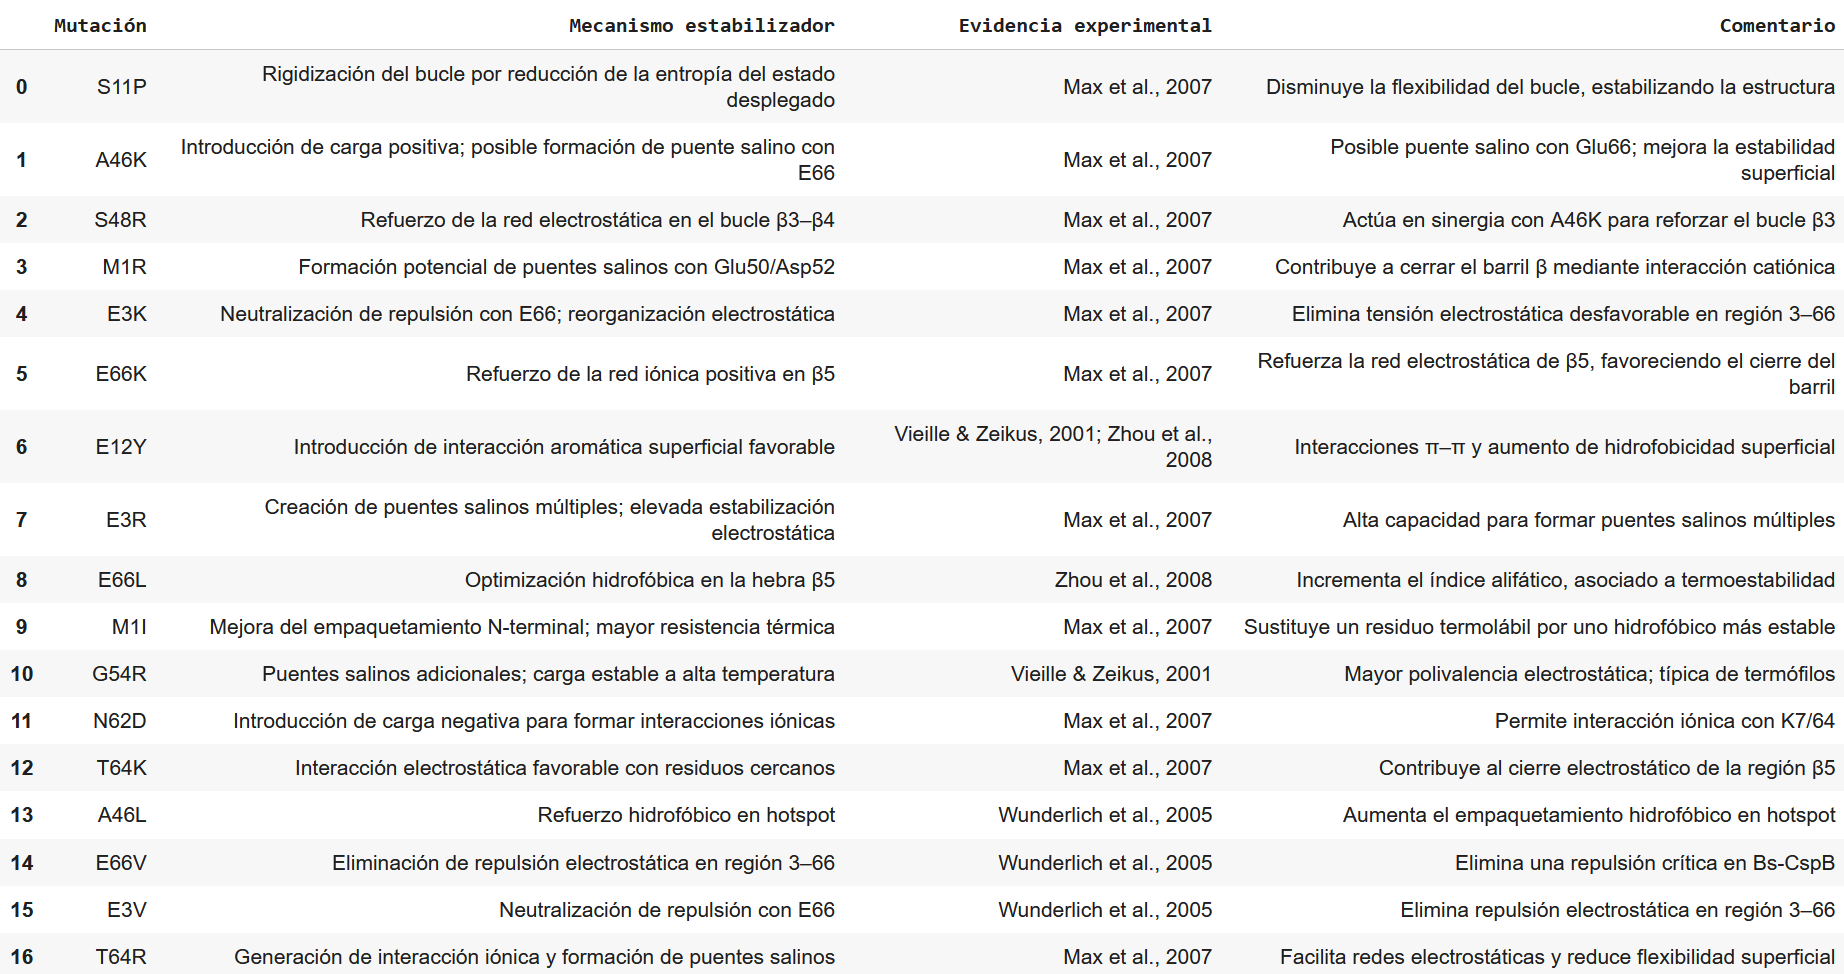

**Diseños basados en el análisis computacional**
***
<div align="justify">

-**Diseño 1 (W8K, S11P, A46K, S48R):** este diseño busca corregir un *hotspot* energético desfavorable en la región terminal (W8K), rigidizar el primer bucle (S11P) y optimizar la red electrostática del tercer bucle (A46K/S48R) para incrementar la estabilidad térmica local.

*   **W8K**: la mutagénesis virtual identificó la posición 8 como un *hotspot* desfavorable (ΔΔE = −2.95 REU para W8T). Se seleccionó Lys para introducir una carga positiva, esperando que se formen nuevas interacciones electrostáticas o enlaces de hidrógeno solventados que compensen la desestabilización local.

*   **S11P**: la Ser11 se localiza en un bucle. La introducción de Pro restringe la flexibilidad del esqueleto peptídico (mayor rigidez), reduciendo la entropía conformacional del estado desnaturalizado.

*   **A46K**: se predijo una ganancia de estabilidad al introducir una carga positiva en esta región (ΔΔE = −0.48 REU para A46K), además se espera que forme un puente salino con el residuo Glu66 (próximos en espacio) para reforzar la red electrostática superficial.

*   **S48R**: la Arg48 introduce otra carga positiva en el mismo bucle para reforzar la interacción electrostática. Esta mutación depende de la orientación tridimensional de los rotámeros para evitar repulsiones entre cargas adyacentes (como con la Lys46).



-**Diseño 2 (K13L, F30A, T64V):** este diseño se enfoca en optimizar el empaquetamiento entre el núcleo y la superficie, eliminando repulsiones estéricas y mejorando las interacciones hidrofóbicas en los bordes de la hoja β.

*   **K13L**: el análisis computacional indicó que K13L es un cambio favorable (ΔΔE = −0.6 REU), ya que la Leu está eliminando una cadena lateral cargada por una hidrofóbica, reduciendo el coste entálpico de solvatación y permitiendo cubrir un parche hidrofóbico expuesto (mejora del empaquetamiento local).

*   **F30A**: se predijeron colisiones estéricas en la Phe30, por lo tanto, al añadir una Ala se alivia dicho impedimento estérico, aunque puede desestabilizar la proteína si la interacción aromática de Phe30 es esencial en el núcleo proteico.

*   **T64V**: se identificó como un *hotspot* favorable (ΔΔE = −0.925 REU). La Val incrementa el carácter hidrofóbico en el borde de la hoja β, optimizando el empaquetamiento si el grupo hidroxilo de Thr64 no es esencial en la red de enlaces de hidrógeno.



-**Diseño 3 (N10D, Q34L, A67S):** el diseño combina tres de los *hotspots* más estabilizantes identificados por el escaneo virtual de mutagénesis para maximizar la ganancia energética global.

*   **N10D (ΔΔE = −1.50 REU)**: introduce una carga negativa en el primer bucle con el fin de formar interacciones electrostáticas favorables o estabilizando redes de enlaces de hidrógeno.

*   **Q34L (ΔΔE = −1.52 REU)**: reemplaza un residuo polar por uno hidrofóbico para mejorar el empaquetamiento y la cohesión local del núcleo.

*   **A67S (ΔΔE = −1.07 REU)**: incorpora un grupo hidroxilo terminal capaz de formar un enlace de hidrógeno de anclaje (reduce la flexibilidad de la cola C-terminal).

</div>

**Diseños basados en estrategias de termoestabilización (Tabla 1)**
***
<div align="justify">

-**Diseño 4 (M1R, E3K, E66K):** Introduce una red de cargas positivas en torno a las hebras β1 y β5, compensando la fuerte densidad negativa nativa de Bs-CspB. Las mutaciones refuerzan el cierre del barril β mediante puentes salinos potenciales, una estrategia descrita en mutantes altamente termoestables (Max et al., 2007).



-**Diseño 5 (E12Y, A46K, S48R):** combinación de la introducción de interacciones aromáticas superficiales (E12Y) con la creación de una red iónica intercatenaria entre hebras β1 y β4 (A46K/S48R). El diseño incrementa la rigidez del barril mediante interacciones π y puentes salinos cooperativos
(Vieille & Zeikus, 2001; Zhou et al., 2008).



-**Diseño 6 (E3R, E66L, A46K, S48R):** este diseño se centra en la optimización de la superficie electrostática y la eliminación de interacciones desfavorables en la región que comprende las hebras β1, β4 y β5. Basado en datos experimentales de Max et al. (2007) para Bs-CspB, donde E3R (≈ 16 kJ mol⁻¹) y el par A46K/S48R (≈ 11.1 kJ mol⁻¹) mostraron contribuciones sinérgicas, se espera una ganancia total de energía libre de estabilización superior a 20 kJ mol⁻¹.



-**Diseño 7 (E3R, M1I, A46K, S48R):** es una variante del diseño D06 que reemplaza la metionina N-terminal (termolábil y susceptible a la oxidación) por isoleucina, mejorando el empaquetamiento hidrofóbico en el extremo N-terminal. Se mantiene la red iónica A46K/S48R (Max et al., 2007).



-**Diseño 8 (G54R, N62D, T64K):** este diseño optimiza las interacciones en la hebra β5, adyacente a la β1, para estabilizar el cierre del barril β. Se introducen dos cargas positivas (G54R y T64K) y una negativa (N62D) para generar una red de interacciones iónicas cooperativas, reforzando el cierre del barri y reduciendo la flexibilidad terminal (Vieille & Zeikus, 2001; Max et al., 2007).



-**Diseño 9 (A46L, E66V):** este diseño combina la optimización hidrofóbica en un *hotspot* (A46L) y la neutralización de repulsiones electrostáticas superficiales entre Glu3 y Glu66 (E66V), basándose en los hallazgos de Wunderlich et al. (2005) para el empaquetamiento y el alivio electrostático de la proteína Bs-CspB.



-**Diseño 10 (E3V, A46L, T64R, E66V):** este diseño integra los efectos de D09 (A46L + E66V) con la eliminación de la repulsión de Glu3 (E3V) y la introducción de una carga positiva capaz de formar puentes salinos (T64R). Produce una reorganización electrostática más favorable y un refuerzo hidrofóbico moderado, optimizando dos zonas críticas de inestabilidad(Wunderlich et al., 2005).

</div>

## **3. Resultados**

<div align="justify">

Se generaron y analizaron diez variantes de la proteína Bs-CspB (PDB: 1CSP) con el objetivo de aumentar su estabilidad térmica mediante mutaciones racionales. Para cada diseño se calcularon, tras la relajación estructural con PyRosetta, la energía total (*score*), los términos energéticos individuales y los parámetros que describen la estabilidad (ΔΔG, ΔTm estimado, RMSD, número de mutaciones y puentes salinos). Los valores individuales de los términos energéticos para cada diseño se muestran en la **Tabla 2**, mientras que los resultados globales y los parámetros derivados se resumen en la **Tabla 3**. Los diez diseños (D01–D10) mostraron valores de score total comprendidos entre –211.8 y –221.9 REU, todos inferiores al *wild type* (WT, –209.8 REU). Los ΔΔG variaron de –2.0 a –12.1 REU y todas las estructuras presentaron RMSD < 0.4 Å.

</div>

**Tabla 2. Desglose energético comparativo (en REU) de la variante *wild type* (WT) y los diez diseños.**
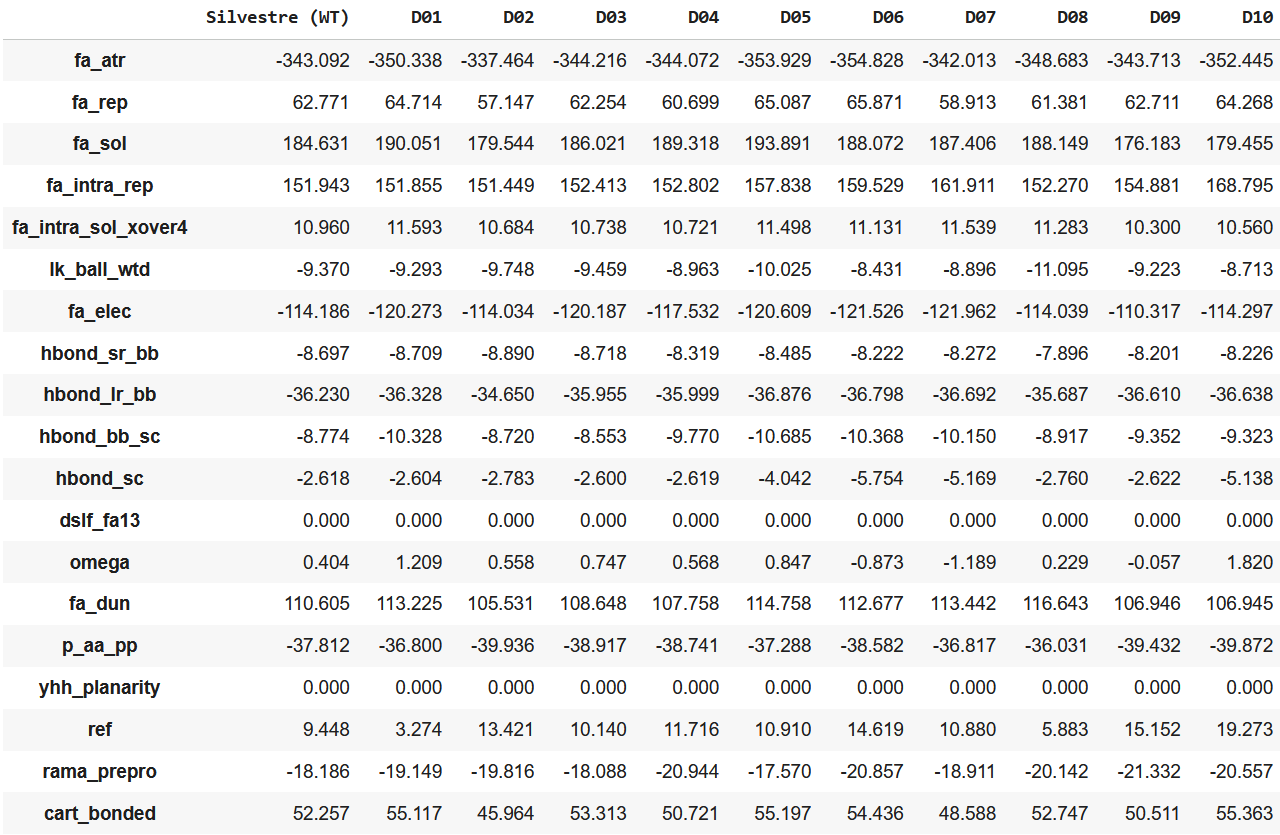

**Tabla 3. Resumen comparativo de las métricas de estabilidad y calidad estructural de los diseños.** El "Score estabilidad" y la columna "Exitoso" se utilizan para clasificar el potencial de cada variante frente a la proteína *wild type* de referencia.
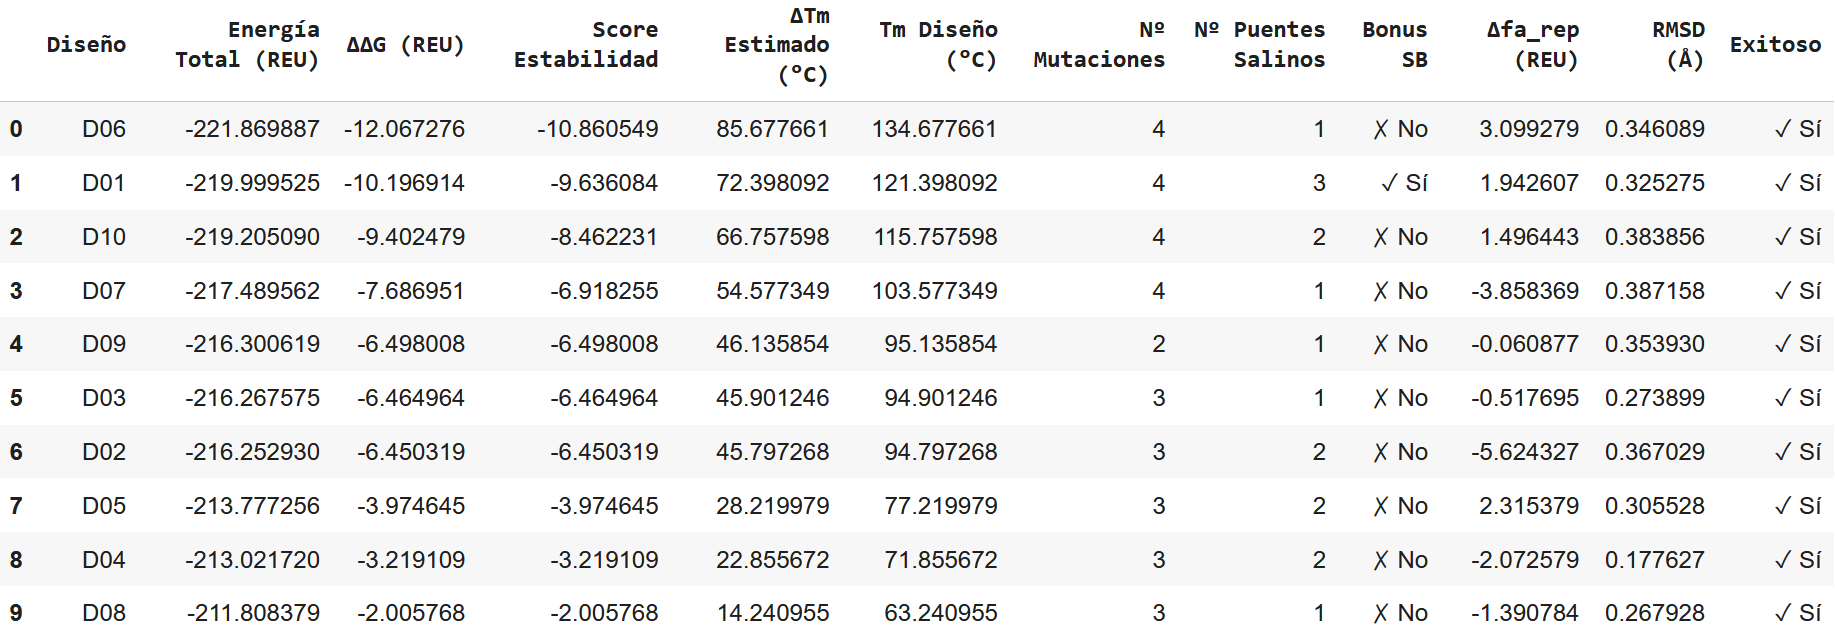

<div align="justify">

En la **Figura 2** se muestra la superposición de la estructura tridimensional de cada uno de los diseños abordados en el proyecto que evidencian la similitud estructural a la proteína *wild type*.

</div>

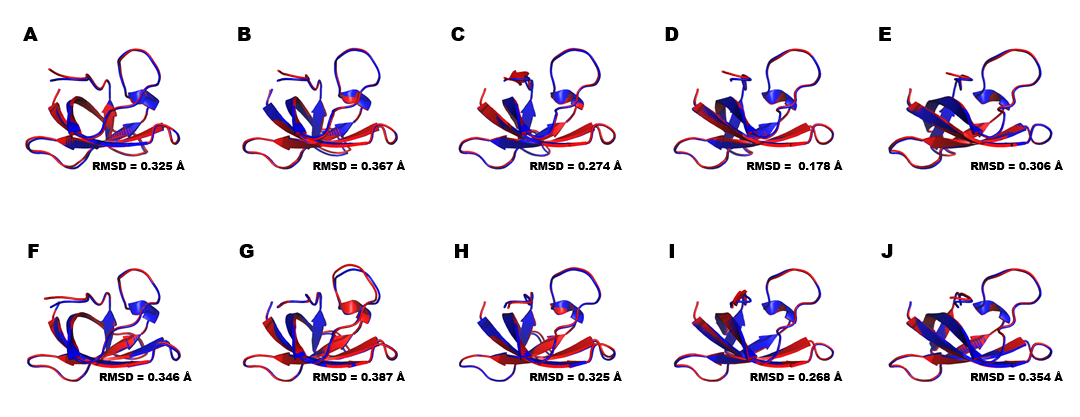

**Figura 2. Superposición estructural de los diez diseños (rojo) sobre la estructura WT de referencia (azul).** Los paneles (A-J) corresponden a los diseños D01-10, respectivamente.

<div align="justify">

El diseño D06 presentó el *score* total más bajo (–221.87 REU) y el valor de ΔΔG más favorable (–12.07 REU). El ΔTm estimado a partir de este valor fue de aproximadamente +86 °C respecto al WT, lo que corresponde a una Tm teórica de 134.7 °C. D06 contiene cuatro mutaciones y un puente salino. En términos energéticos individuales destacan un valor de `fa_atr` de –354.8 REU, el más negativo del conjunto, y una energía electrostática (`fa_elec`) de –121.5 REU. El valor de `fa_rep` (65.9 REU) se mantiene dentro de los márgenes definidos para estructuras compactas.

En segundo lugar, el diseño D01 mostró un *score* total de –219.99 REU y un ΔΔG de –10.2 REU, con un ΔTm estimado de +72 °C. Presenta cuatro mutaciones confirmadas y tres puentes salinos.

Los diseños D10 y D07 obtuvieron puntuaciones totales de –219.21 REU y –217.49 REU, y valores de ΔΔG de –9.4 REU y –7.69 REU, respectivamente. Ambos diseños incorporaron cuatro mutaciones. Específicamente, el diseño D10 contiene dos puentes salinos, con un valor de `fa_rep` de 64.3 REU y un ΔTm estimado de +67 °C. Por su parte, el diseño D07 presenta un único puente salino, con un `fa_rep` de 58.9 REU y un ΔTm estimado de +55 °C. Cabe destacar que los valores de `fa_rep` para ambos diseños se encuentran dentro de los límites establecidos.

Los diseños D02, D03 y D09 mostraron valores de *score* total entre –216.3 y –216.25 REU y ΔΔG en el rango –6.45 a –6.50 REU, con incrementos de temperatura de fusión estimados de +45 a +46 °C. D02 contiene tres mutaciones y dos puentes salinos, D03 tres mutaciones y un puente salino, y D09 dos mutaciones y un puente salino. En D02 destaca el valor más bajo de `fa_rep` (57.15 REU), mientras que D03 presenta un valor de `fa_elec` más negativo (–120.2 REU).

El diseño D05 obtuvo un ΔΔG de –3.97 REU y un *score* total de –213.78 REU. El diseño D04 presentó ΔΔG de –3.22 REU y *score* de –213.02 REU, y el diseño D08 los valores menos favorables (ΔΔG = –2.01 REU, *score* = –211.81 REU). En estos tres casos, el número de mutaciones fue de tres y los puentes salinos variaron entre uno y dos. Los valores de `fa_atr` oscilaron entre –348.6 y –353.9 REU, y los de `fa_rep` entre 60.7 y 65.1 REU.

En el conjunto de los diez diseños, el término fa_atr presentó valores más negativos que el WT (–343.1 REU), con D06 (–354.8 REU) y D05 (–353.9 REU) como los más destacados. El `fa_rep` no superó el incremento máximo permitido (+20 REU respecto al WT = 62.77 REU), siendo los más bajos los de D02 (57.15 REU) y D07 (58.91 REU). El `fa_elec` mostró mejoras generalizadas, especialmente en D07 (–121.96 REU) y D06 (–121.53 REU). Los términos `hbond_sr_bb`/`lr_bb` se mantuvieron estables en todos los diseños (–8 a –37 REU) y `fa_sol` varió entre 176 y 194 REU.

</div>

## **4. Discusión**

<div align="justify">

El análisis comparativo de las diez variantes diseñadas de Bs-CspB permite establecer una relación directa entre las modificaciones introducidas y los efectos observados sobre la estabilidad termodinámica. En todos los casos, las simulaciones confirmaron la conservación del pliegue tipo barril β característico de las CSPs, con valores de RMSD inferiores a 0.4 Å respecto al *wild type* (Zeeb & Balbach, 2003). Este resultado demuestra que las mutaciones propuestas actúan principalmente sobre la superficie y las regiones de loop, reforzando interacciones laterales y cargas sin perturbar el marco estructural del esqueleto proteico (Wunderlich et al., 2005; Max et al., 2007).

Entre los diseños analizados, D06 representa la variante más termoestable, con un ΔΔG de –12.07 REU y un incremento estimado de temperatura de fusión de +86 °C. Su perfil energético revela una reducción notable en la energía electrostática (`fa_elec`= –121.5 REU) y una fuerte atracción de Van der Waals (`fa_atr`= –354.8 REU), lo que indica un empaquetamiento hidrofóbico más eficiente y una redistribución favorable de las cargas. A pesar de presentar un solo puente salino, la magnitud de su estabilización sugiere que las mutaciones contribuyen a optimizar tanto las interacciones de corto alcance como la complementariedad entre residuos polares y apolares. Este comportamiento concuerda con observaciones experimentales en homólogos termófilos, donde la cooperatividad entre interacciones hidrofóbicas y contactos electrostáticos constituye un determinante principal de la termoestabilidad (Ponnuswamy et al., 1982; Wunderlich et al., 2005; Max et al., 2007).

El diseño D01, con ΔΔG de –10.2 REU y ΔTm estimado de +72 °C, se aproxima al rendimiento de D06, aunque su mecanismo de estabilización difiere. La introducción de tres puentes salinos adicionales ejerce un efecto claramente favorable, ya que estos enlaces iónicos entre residuos de carga opuesta refuerzan la red electrostática superficial y reducen la movilidad conformacional de los loops (Zhou et al., 2008). En sistemas termófilos, este tipo de interacciones contribuye significativamente a la estabilidad por su carácter direccional y su capacidad para mantener contactos fuertes incluso a altas temperaturas, compensando las pérdidas entrópicas asociadas al desorden térmico (Vieille & Zeikus, 2001). Así, la ganancia energética observada en D01 se atribuye a una sinergia entre la rigidización estructural inducida por los puentes salinos y la optimización de interacciones hidrofóbicas, evidenciada por un valor de `fa_atr` más negativo que en el *wild type* (Wunderlich et al., 2005; Max et al., 2007).

Los diseños D10 y D07 también mostraron incrementos de estabilidad significativos (ΔΔG de –9.4 REU y –7.69 REU, respectivamente), con ΔTm estimados de +67 y +55 °C. En ambos casos, el número de mutaciones (cuatro) y los valores de `fa_rep` moderados (64.3 REU en D10 y 58.9 REU en D07) indican estructuras compactas y libres de tensiones locales (Vieille & Zeikus, 2001). D10, con dos puentes salinos, y D07, con uno, confirman que incluso un número reducido de enlaces iónicos estratégicamente situados puede mejorar sustancialmente la cohesión electrostática. En particular, el término `fa_elec` de D07 (–121.96 REU, el más favorable del conjunto) evidencia una reorganización eficiente de las cargas, fortaleciendo la red superficial y favoreciendo la atracción entre dominios cargados de signo opuesto (Wunderlich et al., 2005; Max et al., 2007).

Los diseños D02, D03 y D09, con ΔΔG en torno a –6.5 REU y aumentos de temperatura de fusión de +45 a +46 °C, constituyen ejemplos de estabilización moderada mediante un número reducido de mutaciones (2–3). En D02, el valor más bajo de `fa_rep` (57.15 REU) refleja un ajuste espacial óptimo que minimiza las colisiones estéricas internas, mientras que en D03, el valor más negativo de `fa_elec` (–120.2 REU) apunta a una mejora del entorno electrostático. Aunque estas variantes generan menos puentes salinos que D01, sus resultados demuestran que la reducción de tensiones internas y el refuerzo de interacciones locales pueden contribuir de forma equivalente a la estabilidad térmica, especialmente cuando se preservan los patrones de puentes de hidrógeno del esqueleto (`hbond_sr_bb`/`lr_bb` estables) (Vieille & Zeikus, 2001; Wunderlich et al., 2005; Max et al., 2007).

Por el contrario, las variantes D05, D04 y D08 presentaron los menores incrementos de estabilidad (ΔΔG entre –2.0 y –4.0 REU). En D05, el valor muy favorable de `fa_atr` (–353.9 REU) se ve parcialmente compensado por un aumento de `fa_rep` (65.1 REU), lo que sugiere una compactación excesiva con tensiones locales. D08 y D04, con uno y dos puentes salinos respectivamente y valores energéticos cercanos al *wild type*, mantuvieron el pliegue barril β sin incorporar suficientes interacciones cooperativas adicionales para generar un efecto estabilizador notable. Estas observaciones refuerzan la idea de que la posición y orientación de las mutaciones son tan determinantes como su número, y que la mera introducción de cargas opuestas no garantiza una mejora energética si no se integran en la red iónica preexistente (Vieille & Zeikus, 2001; Wunderlich et al., 2005; Max et al., 2007).

El análisis global de los términos energéticos muestra una tendencia clara: los diseños más estables presentan simultáneamente valores más negativos de `fa_atr` y `fa_elec` y niveles moderados de `fa_rep`, reflejando un balance favorable entre fuerzas hidrofóbicas, interacciones de carga y estabilidad estructural (Kumar et al., 2000). Los términos de puentes de hidrógeno backbone (`hbond_sr_bb`/`lr_bb`) se mantuvieron invariables, confirmando que la estabilización procede principalmente de efectos de superficie y reorganización lateral, más que de cambios en la arquitectura del núcleo (Zhou et al., 2008). En este contexto, los puentes salinos emergen como un factor clave, ya que su presencia no solo contribuye a la energía electrostática neta, sino que reduce la entropía del estado desplegado y refuerza la red cooperativa de interacciones locales, tal como se ha descrito en proteínas termófilas naturales (Vieille & Zeikus, 2001; Wunderlich et al., 2005; Max et al., 2007).

Desde un punto de vista metodológico, el uso de una semilla fija en la simulación permitió controlar la variabilidad estocástica del protocolo de relajación y diseño, garantizando la reproducibilidad de los resultados. Sin embargo, se reconoce que un enfoque basado en réplicas independientes sin fijar la semilla, aunque computacionalmente más exigente, proporcionaría una estimación más robusta de la variabilidad de las energías y un análisis más extrapolable al ámbito experimental. Esta estrategia se considera una mejora metodológica de interés para futuros estudios (Robertson & Murphy, 1997; Shi et al., 2025).

</div>

## **5. Conclusión**

<div align="justify">

En conjunto, los resultados obtenidos confirman que la combinación de diseño racional y simulación computacional permite modular de manera precisa la estabilidad térmica de Bs-CspB mediante un número reducido de mutaciones estratégicamente situadas. Las variantes D06 y D01 constituyen ejemplos de éxito en los que la optimización cooperativa de interacciones hidrofóbicas y electrostáticas, junto con la formación de puentes salinos, produce un aumento sustancial de la estabilidad sin alterar la conformación nativa. Este trabajo refuerza la utilidad de Bs-CspB como modelo para el estudio de los principios moleculares de la termoestabilidad y pone de manifiesto el potencial de PyRosetta como herramienta de predicción en el diseño computacional de proteínas termoestables.

</div>

## **6. Bibliografía**

<div align="justify">

1. Graumann, P., Wendrich, T. M., Weber, M. H. W., Schröder, K., & Marahiel, M. A. (1997). A family of cold shock proteins in Bacillus subtilis is essential for cellular growth and for efficient protein synthesis at optimal and low temperatures. Molecular Microbiology, 25(4), 741–756. https://doi.org/10.1046/j.1365-2958.1997.5121878.x

2. Kumar, S., Tsai, C. J., & Nussinov, R. (2000). Factors enhancing protein thermostability. Protein Engineering, 13, 179–191. https://doi.org/10.1093/protein/13.3.179

3. Lopez, M. M., Yutani, K., & Makhatadze, G. I. (1999). Interactions of the major cold shock protein of Bacillus subtilis CspB with single-stranded DNA templates of different base composition. The Journal of Biological Chemistry, 274(47), 33601–33608. https://doi.org/10.1074/jbc.274.47.33601

4. Max, K. E., Wunderlich, M., Roske, Y., Schmid, F. X., & Heinemann, U. (2007). Optimized variants of the cold shock protein from in vitro selection: structural basis of their high thermostability. Journal of Molecular Biology, 369(4), 1087–1097. https://doi.org/10.1016/j.jmb.2007.04.016

5. Ponnuswamy, P. K., Muthusamy, R., & Manavalan, P. (1982). Amino acid composition and thermal stability of proteins. International Journal of Biological Macromolecules, 4(3), 186–190. https://doi.org/10.1016/0141-8130(82)90049-6

6. Robertson, A. D., & Murphy, K. P. (1997). Protein structure and the energetics of protein stability. Chemical Reviews, 97, 1251–1267. https://doi.org/10.1021/cr960383c

7. Sachs, R., Max, K. E. A., Heinemann, U., & Balbach, J. (2012). RNA single strands bind to a conserved surface of the major cold shock protein in crystals and solution. RNA, 18(1), 65–76. https://doi.org/10.1261/rna.02809212

8. Shi, J., Yuan, B., Yang, H., & Sun, Z. (2025). Recent advances on protein engineering for improved stability. BioDesign Research, 7(1), 100005. https://doi.org/10.1016/j.bidere.2025.100005

9. Taneja, S., & Ahmad, F. (1994). Increased thermal stability of proteins in the presence of amino acids. The Biochemical Journal, 303(Pt 1), 147–153. https://doi.org/10.1042/bj3030147

10. Vieille, C., & Zeikus, G. J. (2001). Hyperthermophilic enzymes: sources, uses, and molecular mechanisms for thermostability. Microbiology and Molecular Biology Reviews, 65, 1–43. https://doi.org/10.1128/mmbr.65.1.1-43.2001

11. Willimsky, G., Bang, H., Fischer, G., & Marahiel, M. A. (1992). Characterization of cspB, a Bacillus subtilis inducible cold shock gene affecting cell viability at low temperatures. Journal of Bacteriology, 174(20), 6326–6335. https://doi.org/10.1128/jb.174.20.6326-6335.1992

12. Wunderlich, M., Martin, A., & Schmid, F. X. (2005). Stabilization of the cold shock protein CspB from Bacillus subtilis by evolutionary optimization of Coulombic interactions. Journal of Molecular Biology, 347(5), 1063–1076. https://doi.org/10.1016/j.jmb.2005.02.014

13. Zeeb, M., & Balbach, J. (2003). Single-stranded DNA binding of the cold-shock protein CspB from Bacillus subtilis: NMR mapping and mutational characterization. Protein Science, 12(1), 112–123. https://doi.org/10.1110/ps.0219703

14. Zhou, X. X., Wang, Y. B., Pan, Y. J., et al. (2008). Differences in amino acids composition and coupling patterns between mesophilic and thermophilic proteins. Amino Acids, 34, 25–33. https://doi.org/10.1007/s00726-007-0589-x

</div>